### Calibration of pressure sensor with temperature compensation 🌡️

last version (2025-09-29)

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from pathlib import Path
import sys
try:
    from ruamel.yaml import YAML
    yaml = YAML(typ="safe")
    yaml.indent(mapping=2, sequence=4, offset=2)
    # yaml.explicit_start=False
    yaml_safe_load = yaml.load
except ImportError:
    import yaml
    yaml_safe_load = yaml.safe_load
    print("ruamel.yaml not found, using yaml instead")
# from scipy.optimize import curve_fit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [ ]:
# Load probe mean values of recorded voltage, V and temperature, °C:
path_in = Path(
    rf"B:\WorkData\experiment\inclinometer\260624@ip05-Press\_raw\vsz\260624_1442_dt=10h@i_p5-press-to_fit-x_values.tsv"
)  # produced as sideeffect in vsz by ~save2text expression, after creating intervals_selected@ip05.txt using
# with help of same vsz `Read data points` tool manually,
# converting v.vsz2dt64([vsz-time of start and end of each interval]
# - put it in one `time_edges` column or in two (`time_edges	time_end`) columns

u, t = np.loadtxt(path_in, skiprows=1, dtype=("f8",) * 2, delimiter="\t", unpack=True)
pid = path_in.name.split("@", 1)[1].split("-", 1)[0]
print(f"Loaded data from probe ID {pid=}")

# Real pressure, dBar, that was possible to apply
ref_possible = np.arange(11) * 9.80665  # 1 (кгс/см²)/dBar = 9.80665

# Atmospheric pressure, dBar:
# also can got from st 26708 in Низовье: https://rp5.ru/Архив_погоды_в_Низовье_(метеостанция)
y_a = np.float64([1015.3, 1015.3, 1015.0, 1014.9]) * 0.01 # from mBar to dBar  # from mm use 0.0133322 dBar/mm
# y_a_time_h = [14, 17, 20]  # 14:00 - 20:00
# y_exp_time = ["14:45", "15:40", "16:55", "17:47"]  # measurement time between big temperature changes (sorted)

Loaded data from probe ID pid='i_p5'


In [38]:
# # Atmospheric pressure corresponding to `y_exp_time`
# def time_to_decimal(time_str):
#     h, m = map(int, time_str.split(":"))
#     return h + m / 60.0

# y_exp_time_h = [time_to_decimal(t) for t in y_exp_time]
y_a_in_order = y_a  # np.interp(y_exp_time_h, y_a_time_h, y_a)
# display(f"{ref_possible=}", f"{y_a_in_order=}", f"{y_exp_time_h=}")

# Find when each real pressure was applied
i_p = np.int8([
    np.argmin(abs(ref_possible - u_cur))
    for u_cur in np.min(ref_possible)
    + (np.max(ref_possible) - np.min(ref_possible)) * (u - np.min(u)) / (np.max(u) - np.min(u))
])
y_dif = ref_possible[i_p].flatten()
print(f"{i_p=}\n{y_dif=}")

i_p=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  0,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
        0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int8)
y_dif=array([ 0.     ,  9.80665, 19.6133 , 29.41995, 39.2266 , 49.03325,
       58.8399 , 68.64655, 78.4532 , 88.25985, 98.0665 ,  0.     ,
        0.     ,  9.80665, 19.6133 , 29.41995, 39.2266 , 49.03325,
       58.8399 , 68.64655, 78.4532 , 88.25985, 98.0665 ,  0.     ,
        9.80665, 19.6133 , 29.41995, 39.2266 , 49.03325, 58.8399 ,
       68.64655, 78.4532 , 88.25985, 98.0665 ,  0.     ,  9.80665,
       19.6133 , 29.41995, 39.2266 , 49.03325, 58.8399 , 68.64655,
       78.4532 , 88.25985, 98.0665 ])


In [39]:
# Find when each atmospheric pressure was applied
i_exp = np.cumsum(np.ediff1d(i_p, to_begin=0) < 0)
y_a = y_a_in_order[i_exp]

# Standard atmosphere (we calibrate relative to this reference), dBar
y_0 = 1013.25 / 100

print(f"{y_a=}\n{y_0=}\n{i_exp=}")

y_a=array([10.153, 10.153, 10.153, 10.153, 10.153, 10.153, 10.153, 10.153,
       10.153, 10.153, 10.153, 10.153, 10.153, 10.153, 10.153, 10.153,
       10.153, 10.153, 10.153, 10.153, 10.153, 10.153, 10.153, 10.15 ,
       10.15 , 10.15 , 10.15 , 10.15 , 10.15 , 10.15 , 10.15 , 10.15 ,
       10.15 , 10.15 , 10.149, 10.149, 10.149, 10.149, 10.149, 10.149,
       10.149, 10.149, 10.149, 10.149, 10.149])
y_0=10.1325
i_exp=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3])


In [44]:
y = y_dif + y_a - y_0

df = pd.DataFrame.from_dict({
    "iPdif": i_p,
    "Pdif": y_dif,
    "Pa": y_a,
    "u": u,
    "t": t,
    "P": y,
    "du": np.ediff1d(u, to_end=np.nan),
})
print(
    "iPdif - index of possible pressure differences applied,\n"
    "Pdif - Applied pressure difference; Pa - atmospheric, dBar;\n"
    f"P - Real pressure relative to Standard atmosphere {y_0} dBar;\n"
    "u - pressure PCB output voltage, V; t - temperature, °C\n",
    df
)
x = df[['u', 't']]
print(f'Samples x features {tuple(x.columns)} size: {x.shape}')

iPdif - index of possible pressure differences applied,
Pdif - Applied pressure difference; Pa - atmospheric, dBar;
P - Real pressure relative to Standard atmosphere 10.1325 dBar;
u - pressure PCB output voltage, V; t - temperature, °C
     iPdif      Pdif      Pa            u       t         P           du
0       0   0.00000  10.153   242865.529   5.087   0.02050   255721.701
1       1   9.80665  10.153   498587.230   5.047   9.82715   249333.503
2       2  19.61330  10.153   747920.733   5.020  19.63380   251173.524
3       3  29.41995  10.153   999094.257   4.982  29.44045   252067.829
4       4  39.22660  10.153  1251162.086   4.953  39.24710   251850.600
5       5  49.03325  10.153  1503012.686   4.913  49.05375   251485.132
6       6  58.83990  10.153  1754497.818   4.883  58.86040   251176.755
7       7  68.64655  10.153  2005674.573   4.854  68.66705   250707.139
8       8  78.45320  10.153  2256381.712   4.830  78.47370   250276.785
9       9  88.25985  10.153  2506658.497   

In [41]:
# Define our polynomial model, with whatever degree we want
degrees = [1, 2]
for degree in degrees:
    # PolynomialFeatures will create a new matrix consisting of all polynomial combinations
    # of the features with a degree less than or equal to the degree we just gave the model (2)
    poly_model = PolynomialFeatures(degree=degree, include_bias=False)

    # Transform out polynomial features
    poly_x = poly_model.fit_transform(x)
    # For degree=2 should be in the form [1, a, b, a^2, ab, b^2]
    # print(f'initial values {x[0]} mapped to:\n{poly_x[0]}')
    coef_cols = poly_model.get_feature_names_out()

    # Fit the model
    regr = LinearRegression()  # we use linear regression as a base!!! ** sometimes misunderstood **
    regr.fit(poly_x, y)

    y_pred = regr.predict(poly_x)
    print(f"Fitted polynom of degree {degree}: ", end="")
    str_poly = (
        " + ".join(
            [f"{regr.intercept_:.6g}"]
            + [
                f"{coef:.6g} * {name.replace(' ', ' * ')}"
                for coef, name in zip(regr.coef_, poly_model.get_feature_names_out())
            ]
        )
    ).replace("+ -", "- ")
    mse = root_mean_squared_error(y, y_pred)
    str_out = f"p = {str_poly}\nMean squared error: {mse:.3g}"

    if degree == degrees[-1]:
        print("We use it below.")
    print(str_out)

path_out = Path(path_in.parent / f"coefs_{pd.Timestamp.now():%y%m%d}.yaml")
try:
    with path_out.open("r") as f:
        loaded_coef = yaml_safe_load(f)
        try:
            data_pid = loaded_coef.pop(pid)
        except KeyError:
            data_pid = {}
    if not loaded_coef:
        loaded_coef = data_pid = {}
except FileNotFoundError:
    loaded_coef = data_pid = {}
with path_out.open("w") as f:
    yaml.dump(
        {
            **loaded_coef,
            pid: {
                **data_pid,
                f"{next(p.split('@', 1)[0] for p in reversed(path_in.parts) if p[:6].isdigit())}": {
                    "poly": str_poly.replace("^", "**"),
                    "mse": round(float(mse), 5),
                    "processed": pd.Timestamp.now().round("h").to_pydatetime(),
                },
            },
        },
        f,
    )

Fitted polynom of degree 1: p = -11.3374 + 3.99048e-05 * u + 0.130641 * t
Mean squared error: 0.572
Fitted polynom of degree 2: We use it below.
p = -9.78972 + 3.84672e-05 * u + 0.0628066 * t + 6.89208e-14 * u^2 + 8.94256e-08 * u * t - 0.00202091 * t^2
Mean squared error: 0.0854


u(min,max): 2.32e+05, 2.76e+06; t(min,max): 4.73, 24.9; P(min,max): 0.0165, 98.1
Errors of fit for experiments with different pressure and temperature:
0.0 dBar: [ 0.08611072  0.07953742 -0.04393891 -0.09919959  0.0317121 ] dBar
9.8 dBar: [-0.07006318 -0.08057042 -0.13507605  0.06911317] dBar
19.6 dBar: [ 0.0144203   0.01802565 -0.05331495  0.11942288] dBar
29.4 dBar: [ 0.02113822  0.06950293 -0.046143    0.07753676] dBar
39.2 dBar: [-0.01547035  0.07498145 -0.06046636  0.04462767] dBar
49.0 dBar: [-0.0490788   0.07675913 -0.06983229  0.0233451 ] dBar
58.8 dBar: [-0.07731582  0.09044941 -0.07631723  0.00456978] dBar
68.6 dBar: [-0.10105866  0.11824652 -0.07461073  0.0055161 ] dBar
78.5 dBar: [-0.11500355  0.16020511 -0.07810621  0.00651849] dBar
88.3 dBar: [-0.11884305  0.18747276 -0.05875629 -0.0059162 ] dBar
98.1 dBar: [-0.1216502   0.21749109 -0.03396982 -0.01200109] dBar


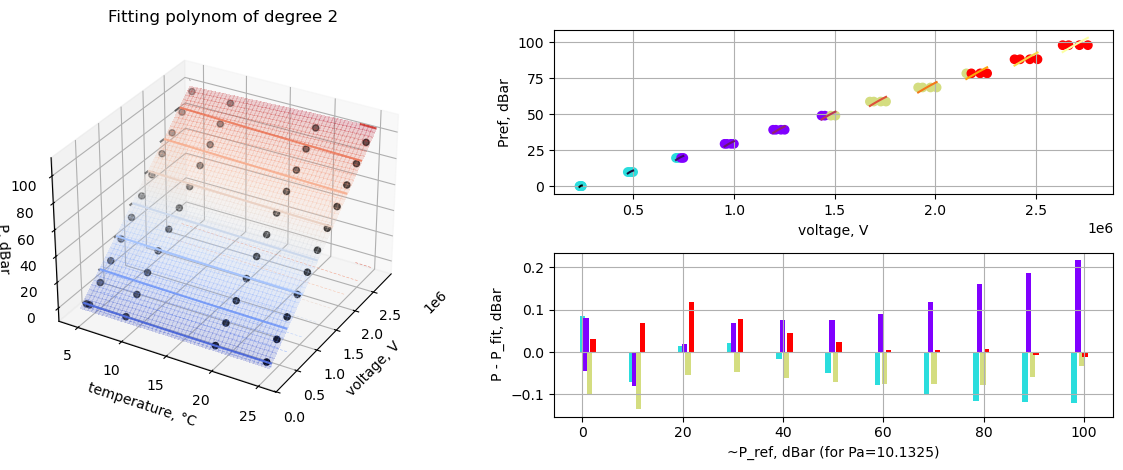

In [50]:
# Show plots
# %matplotlib inline  # is it realy changes something in juputerlab
fig = plt.figure(figsize=plt.figaspect(0.4))
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 4)  # , sharex=ax2 link x axis
(ax1 := fig.add_subplot(1, 2, 1, projection="3d")).view_init(elev=ax1.elev, azim=ax1.azim - 90)
ax1.invert_yaxis()

# Plot result surface
u_min, u_max, t_min, t_max, P_min, P_max = np.min(u), np.max(u), np.min(t), np.max(t), np.min(y), np.max(y)
print(
    "; ".join(
        f"{var}(min,max): {v1:.3g}, {v2:.3g}"
        for var, v1, v2 in (("u", u_min, u_max), ("t", t_min, t_max), ("P", P_min, P_max))
    )
)
ptp_u, ptp_t, ptp_y = u_max - u_min, t_max - t_min, P_max - P_min
n = 50
X = np.linspace(u_min - ptp_u / n, u_max + ptp_u / n, n)
Y = np.linspace(t_min - ptp_t / n, t_max + ptp_t / n, n)
X, Y = np.meshgrid(X, Y)
Z_in = np.column_stack((X.ravel(), Y.ravel()))
Z = regr.predict(poly_model.fit_transform(Z_in)).reshape(X.shape)
surf = ax1.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.2)
# Линии уровня
cs = ax1.contour(X, Y, Z, zdir="z", cmap=cm.coolwarm, linewidths=1.5)
ax1.contour(
    X, Y, Z, zdir="z", offset=Z.min(), cmap=cm.coolwarm, alpha=0.8, linewidths=0.4, linestyles=[(0, (5, 3))],
    # паттерн через кортеж: (смещение, (длина_штриха, длина_пробела, ...)) instead linestyles="dashed"
)  # их проекция на нижнюю грань bounding box

y_wall, x_wall = Y.min(), X.max()  # Координаты плоскостей проекции (границы bounding box)
# Материализация тензора сегментов через list comprehension
# Каждый сегмент: список из двух точек [[x1, y1, z1], [x2, y2, z2]]
segments = [
    seg
    for i, z in enumerate(cs.levels)
    for s in cs.allsegs[i]
    if s.size  # EAFP: отсечение вырожденных путей
    for seg in (
        # Проекция на стену XZ (ось Y коллапсирует в y_wall)
        [[s[:, 0].min(), y_wall, z], [s[:, 0].max(), y_wall, z]],
        # # Проекция на стену YZ (ось X коллапсирует в x_wall)
        # [[x_wall, s[:, 1].min(), z], [x_wall, s[:, 1].max(), z]],
    )
]

# Пакетный рендеринг коллекции (элиминация лишних вызовов .plot)
ax1.add_collection3d(Line3DCollection(segments, colors="k", alpha=0.5, linewidths=1.5))


ax1.scatter3D(*x.values.T, y, color="k")
ax1.set_xlabel("voltage, V")
ax1.set_ylabel("temperature, °C")
ax1.set_zlabel("P, dBar", labelpad=0)  # pressure
ax1.zaxis._auto_rotate_label = False
ax1.zaxis.label.set_rotation(180)
ax1.set_title(f"Fitting polynom of degree {degree}")

# Plot predictions lines for each sub experiment in assumption that external values changes linear between fitting points
# experiment's colors
n_p = max(i_p) + 1
c_press = cm.inferno(np.linspace(0, 1, n_p))

shifts_temps = np.linspace(0, 1, int(round(i_p.size / n_p)))
c_temps = cm.rainbow(shifts_temps)[np.argsort(t[np.ediff1d(i_exp, to_begin=1) != 0])]
# fitting points # Get y order. # addition has no effect if t sorted rev.
isort = np.argsort(i_p + 0.5 * (t_min - t) / ptp_t)
ax2.scatter(x["u"].values[isort], y[isort], c=c_temps[i_exp])  #np.tile(, (n_p, 1)) c_temps[i_exp]
# predictions
print("Errors of fit for experiments with different pressure and temperature:")
scale_bar_width = 1 / (2 * i_p.size)
for i, (c_exp, y_dif_cur) in enumerate(zip(c_press, ref_possible)):
    b_exp = i_p == i  # each t, °C for current Pdif
    x_exp = x[b_exp]
    y_exp = y[b_exp]
    # print(u_exp, t_exp)
    u_min, t_min, u_max, t_max, t_mean = *x_exp.min(), *x_exp.max(), x_exp["t"].mean()
    # print('u(min,max):', u_min, u_max, 't(min,max):', t_min, t_max)
    X = np.linspace(u_min, u_max, n)
    Y = np.linspace(t_min, t_max, n)

    Z_in = np.column_stack((X, Y))
    Z_in_tr = poly_model.fit_transform(Z_in)
    Z = regr.predict(Z_in_tr)
    Z_check = regr.intercept_ + (regr.coef_ * Z_in_tr).sum(axis=1)
    np.testing.assert_array_almost_equal(Z, Z_check)

    ax2.plot(X, Z, color=c_exp, label=f"{t_mean:.1f}±{(t_max - t_min) / 2:.1f}")
    z_diff = (y - y_pred)[b_exp]  # z_diff = y_exp - regr.predict(poly_model.fit_transform(x_exp))
    print(f"{y_dif_cur:.1f} dBar:", z_diff, "dBar")

# Plot residuals


ax3.bar(
    x=y_dif + shifts_temps[i_exp] * ptp_y * scale_bar_width*2,  #np.tile( - 0.1, n_p)
    height=(y - y_pred), # [isort]
    width=ptp_y * scale_bar_width,
    color=c_temps[i_exp],  #np.repeat(, n_p, axis=0) c_temps,  # , label=param
)

# # ax3.plot([u_min, u_max], z_diff, color=c_exp)
# ax3.bar(x=[u_min, u_max], height=z_diff, width=ptp_u/10, color=c_exp)
ax3.set_xlabel(f"~P_ref, dBar (for Pa={y_0})")
ax3.set_ylabel("P - P_fit, dBar")

ax2.set_xlabel("voltage, V")
ax2.set_ylabel("Pref, dBar")
# ax2.legend(title="mean t ±Δt °C")
ax2.grid()
ax3.grid()

plt.tight_layout()
plt.savefig(Path(path_in.parent / f"regression_residuals@{pid}.png"), dpi=300)
plt.show()

In [43]:
df.assign(P_calc=y_pred, ΔP=y - y_pred).to_csv(path_in.parent / f"protocol@{pid}.csv")